# Exploratory Data Analysis (EDA)

This notebook loads the dataset, inspects its structure, summarizes the data, and visualizes key patterns.


In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Find the dataset regardless of the current working directory

def find_dataset(filename: str) -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        matches = list(base.rglob(filename))
        if matches:
            return matches[0]
    raise FileNotFoundError(f"Could not find {filename} in the workspace.")

file_path = find_dataset("house_prices (1).csv")
df = pd.read_csv(file_path)

# Display first few rows
print("First few rows:")
display(df.head())

# Dataset info
print("Dataset info:")
df.info()

# Summary statistics
print("\nSummary statistics:")
display(df.describe(include="all"))

First few rows:


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Property_ID    300 non-null    str  
 1   Area           300 non-null    int64
 2   Bedrooms       300 non-null    int64
 3   Bathrooms      300 non-null    int64
 4   Age            300 non-null    int64
 5   Location       300 non-null    str  
 6   Property_Type  300 non-null    str  
 7   Price          300 non-null    int64
dtypes: int64(5), str(3)
memory usage: 25.2 KB

Summary statistics:


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
count,300,300.00000,300.000000,300.000000,300.000000,300,300,3.000000e+02
unique,300,NaN,NaN,NaN,NaN,3,3,NaN
top,PROP0001,NaN,NaN,NaN,NaN,Suburb,House,NaN
freq,1,NaN,NaN,NaN,NaN,105,107,NaN
mean,NaN,2759.70000,3.033333,2.026667,25.000000,NaN,NaN,2.488366e+07
std,NaN,1297.68143,1.467219,0.792495,14.332646,NaN,NaN,1.266525e+07
min,NaN,520.00000,1.000000,1.000000,0.000000,NaN,NaN,3.695000e+06
25%,NaN,1675.75000,2.000000,1.000000,12.000000,NaN,NaN,1.527750e+07
50%,NaN,2738.00000,3.000000,2.000000,25.500000,NaN,NaN,2.236500e+07
75%,NaN,3801.25000,4.000000,3.000000,36.250000,NaN,NaN,3.460812e+07


## Visualize Distributions

Use histograms for numeric features and countplots for categorical features or the target variable.


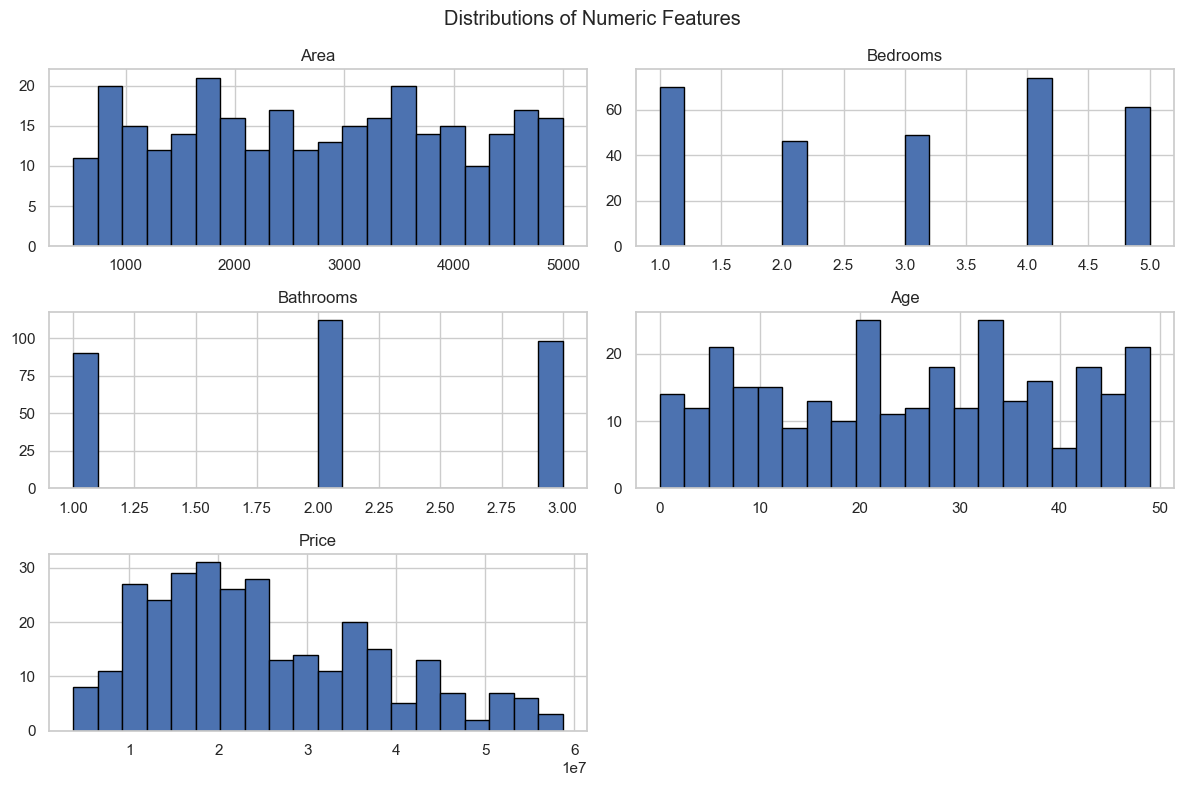

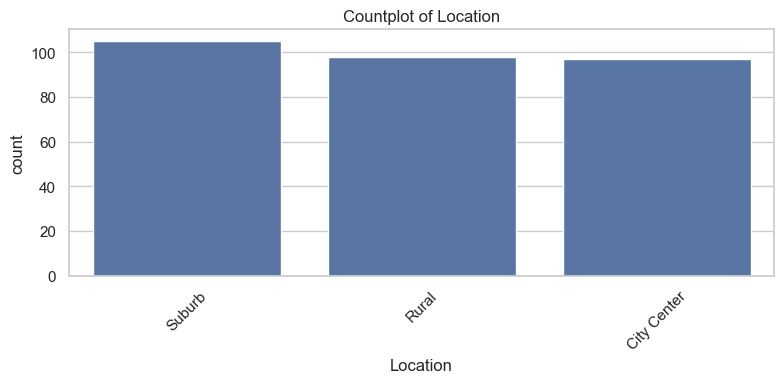

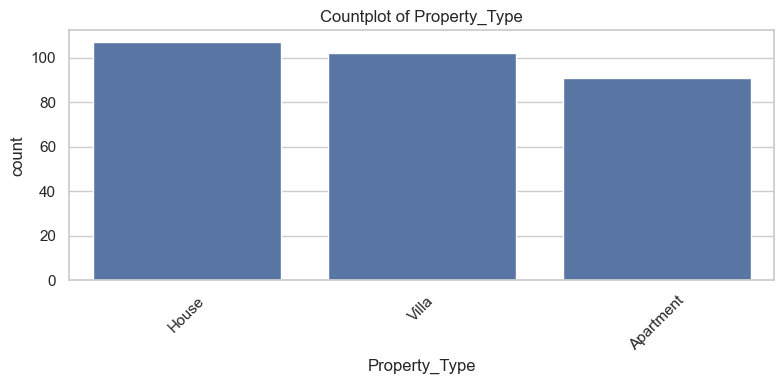

In [4]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = [
    col for col in df.select_dtypes(exclude="number").columns
    if df[col].nunique() <= 10 and col.lower() != "property_id"
]

# Histograms for numeric columns
if numeric_cols:
    df[numeric_cols].hist(figsize=(12, 8), bins=20, edgecolor="black")
    plt.suptitle("Distributions of Numeric Features")
    plt.tight_layout()
    plt.show()

# Countplots for low-cardinality categorical columns
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if not categorical_cols:
    print("No low-cardinality categorical columns found for countplots.")

## Correlation Heatmap

Inspect relationships between numeric features using a correlation heatmap.


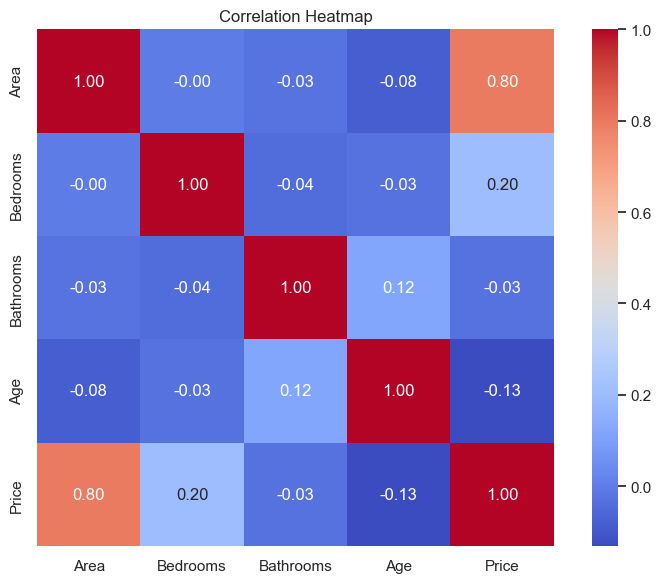

In [5]:
if len(numeric_cols) > 1:
    plt.figure(figsize=(8, 6))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns to compute a correlation heatmap.")